In [2]:
import pandas as pd

df = pd.read_csv("financial_data.csv")
df.head()

,Company,Year,Source,Total Revenue in USD,Net Income in USD,Total Assets in USD,Total Liablilities in USD,Cash Flow from operating activities in USD
0,Microsoft,2022,10K,1.982700e+11,7.273800e+10,3.648400e+11,1.982980e+11,8.903500e+10
1,Microsoft,2023,10K,2.119150e+11,7.236100e+10,4.119760e+11,2.057530e+11,8.758200e+10
2,Microsoft,2024,10K,2.451220e+11,8.813600e+10,5.121630e+11,2.436860e+11,1.185480e+11
3,Tesla,2022,10K,8.146200e+10,1.258700e+10,8.233800e+10,3.644000e+10,1.472400e+10
4,Tesla,2023,10K,9.677300e+10,1.497300e+10,1.066180e+11,4.300900e+10,1.325600e+10


In [3]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Company                                     9 non-null      object 
 1   Year                                        9 non-null      int64  
 2   Source                                      9 non-null      object 
 3   Total Revenue in USD                        9 non-null      float64
 4   Net Income in USD                           9 non-null      float64
 5   Total Assets in USD                         9 non-null      float64
 6   Total Liablilities in USD                   9 non-null      float64
 7   Cash Flow from operating activities in USD  9 non-null      float64
dtypes: float64(5), int64(1), object(2)
memory usage: 708.0+ bytes


Index(['Company', 'Year', 'Source', 'Total Revenue in USD',
       'Net Income in USD', 'Total Assets in USD', 'Total Liablilities in USD',
       'Cash Flow from operating activities in USD'],
      dtype='object')

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df = df.sort_values(['Company', 'Year'])

In [7]:
print(df.columns)

Index(['Company', 'Year', 'Source', 'Total Revenue in USD',
       'Net Income in USD', 'Total Assets in USD', 'Total Liablilities in USD',
       'Cash Flow from operating activities in USD'],
      dtype='object')


In [8]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

print(df.columns)

Index(['company', 'year', 'source', 'total_revenue_in_usd',
       'net_income_in_usd', 'total_assets_in_usd', 'total_liablilities_in_usd',
       'cash_flow_from_operating_activities_in_usd'],
      dtype='object')


In [9]:
df = df.sort_values(['company', 'year'])

df['revenue_growth_%'] = df.groupby('company')['total_revenue_in_usd'].pct_change() * 100

df['net_income_growth_%'] = df.groupby('company')['net_income_in_usd'].pct_change() * 100

df['assets_growth_%'] = df.groupby('company')['total_assets_in_usd'].pct_change() * 100

df['liabilities_growth_%'] = df.groupby('company')['total_liablilities_in_usd'].pct_change() * 100

df['cashflow_growth_%'] = df.groupby('company')['cash_flow_from_operating_activities_in_usd'].pct_change() * 100

df

,company,year,source,total_revenue_in_usd,net_income_in_usd,total_assets_in_usd,total_liablilities_in_usd,cash_flow_from_operating_activities_in_usd,revenue_growth_%,net_income_growth_%,assets_growth_%,liabilities_growth_%,cashflow_growth_%
6,Apple,2022,10K,3.943280e+11,9.980300e+10,3.527550e+11,3.020830e+11,1.221510e+11,NaN,NaN,NaN,NaN,NaN
7,Apple,2023,10K,3.832850e+11,9.699500e+10,3.525830e+11,2.904370e+11,1.105430e+11,-2.800461,-2.813543,-0.048759,-3.855232,-9.502992
8,Apple,2024,10K,3.910350e+11,9.373600e+10,3.649800e+11,3.080300e+11,1.182540e+11,2.021994,-3.359967,3.516052,6.057424,6.975566
0,Microsoft,2022,10K,1.982700e+11,7.273800e+10,3.648400e+11,1.982980e+11,8.903500e+10,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2023,10K,2.119150e+11,7.236100e+10,4.119760e+11,2.057530e+11,8.758200e+10,6.882030,-0.518299,12.919636,3.759493,-1.631942
2,Microsoft,2024,10K,2.451220e+11,8.813600e+10,5.121630e+11,2.436860e+11,1.185480e+11,15.669962,21.800417,24.318650,18.436183,35.356580
3,Tesla,2022,10K,8.146200e+10,1.258700e+10,8.233800e+10,3.644000e+10,1.472400e+10,NaN,NaN,NaN,NaN,NaN
4,Tesla,2023,10K,9.677300e+10,1.497300e+10,1.066180e+11,4.300900e+10,1.325600e+10,18.795267,18.956066,29.488207,18.026894,-9.970117
5,Tesla,2024,10K,9.769000e+10,7.153000e+09,1.220700e+11,4.839000e+10,1.492300e+10,0.947578,-52.227343,14.492862,12.511335,12.575438


In [10]:
df[['company','year','revenue_growth_%','net_income_growth_%']]

,company,year,revenue_growth_%,net_income_growth_%
6,Apple,2022,NaN,NaN
7,Apple,2023,-2.800461,-2.813543
8,Apple,2024,2.021994,-3.359967
0,Microsoft,2022,NaN,NaN
1,Microsoft,2023,6.882030,-0.518299
2,Microsoft,2024,15.669962,21.800417
3,Tesla,2022,NaN,NaN
4,Tesla,2023,18.795267,18.956066
5,Tesla,2024,0.947578,-52.227343


In [11]:
df.groupby('company')['revenue_growth_%'].mean()

,revenue_growth_%
company,
Apple,-0.389233
Microsoft,11.275996
Tesla,9.871422


In [12]:
df.groupby('company')['net_income_in_usd'].mean()

,net_income_in_usd
company,
Apple,9.684467e+10
Microsoft,7.774500e+10
Tesla,1.157100e+10


In [13]:
df.groupby('company')['cash_flow_from_operating_activities_in_usd'].mean()

,cash_flow_from_operating_activities_in_usd
company,
Apple,1.169827e+11
Microsoft,9.838833e+10
Tesla,1.430100e+10


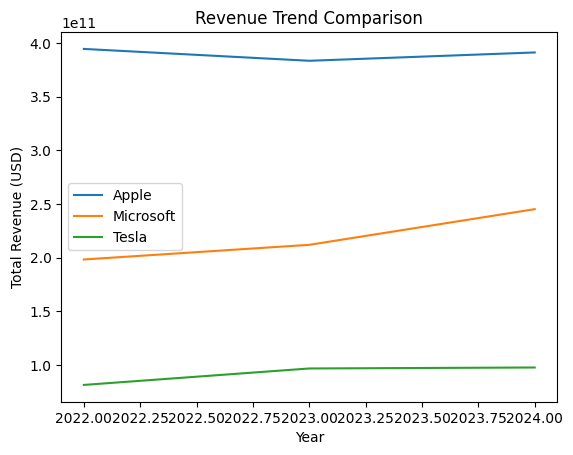

In [14]:
import matplotlib.pyplot as plt

for company in df['company'].unique():
    subset = df[df['company'] == company]
    plt.plot(subset['year'], subset['total_revenue_in_usd'], label=company)

plt.legend()
plt.title("Revenue Trend Comparison")
plt.xlabel("Year")
plt.ylabel("Total Revenue (USD)")
plt.show()

Key Observations

1. Over the three-year period, Microsoft shows steady and consistent revenue growth, supported by relatively stable profitability. This suggests a strong and reliable business model with predictable performance.

2. Tesla, on the other hand, displays noticeable fluctuations in net income. While the company is growing, its profitability appears more volatile, likely reflecting changing production costs, investments, and market dynamics.

3. Apple stands out for maintaining strong and consistent operating cash flows. This indicates efficient operations and a solid ability to generate cash from its core business activities.

4. Across all three companies, total assets have increased over time, which suggests continued expansion and ongoing investment in business growth.








In [15]:
#Profit margin calculation
df['profit_margin_%'] = (df['net_income_in_usd'] / df['total_revenue_in_usd']) * 100
df

,company,year,source,total_revenue_in_usd,net_income_in_usd,total_assets_in_usd,total_liablilities_in_usd,cash_flow_from_operating_activities_in_usd,revenue_growth_%,net_income_growth_%,assets_growth_%,liabilities_growth_%,cashflow_growth_%,profit_margin_%
6,Apple,2022,10K,3.943280e+11,9.980300e+10,3.527550e+11,3.020830e+11,1.221510e+11,NaN,NaN,NaN,NaN,NaN,25.309641
7,Apple,2023,10K,3.832850e+11,9.699500e+10,3.525830e+11,2.904370e+11,1.105430e+11,-2.800461,-2.813543,-0.048759,-3.855232,-9.502992,25.306234
8,Apple,2024,10K,3.910350e+11,9.373600e+10,3.649800e+11,3.080300e+11,1.182540e+11,2.021994,-3.359967,3.516052,6.057424,6.975566,23.971256
0,Microsoft,2022,10K,1.982700e+11,7.273800e+10,3.648400e+11,1.982980e+11,8.903500e+10,NaN,NaN,NaN,NaN,NaN,36.686337
1,Microsoft,2023,10K,2.119150e+11,7.236100e+10,4.119760e+11,2.057530e+11,8.758200e+10,6.882030,-0.518299,12.919636,3.759493,-1.631942,34.146238
2,Microsoft,2024,10K,2.451220e+11,8.813600e+10,5.121630e+11,2.436860e+11,1.185480e+11,15.669962,21.800417,24.318650,18.436183,35.356580,35.955973
3,Tesla,2022,10K,8.146200e+10,1.258700e+10,8.233800e+10,3.644000e+10,1.472400e+10,NaN,NaN,NaN,NaN,NaN,15.451376
4,Tesla,2023,10K,9.677300e+10,1.497300e+10,1.066180e+11,4.300900e+10,1.325600e+10,18.795267,18.956066,29.488207,18.026894,-9.970117,15.472291
5,Tesla,2024,10K,9.769000e+10,7.153000e+09,1.220700e+11,4.839000e+10,1.492300e+10,0.947578,-52.227343,14.492862,12.511335,12.575438,7.322141
